# Patient-Calibrated 3-Stage Random Forest (v3 - Enhanced)

**Overview: The Patient-Calibrated Paradigm**

This notebook evaluates a patient-calibrated Random Forest pipeline for classifying 3 sleep macro-stages (Wake, NREM, REM) using exclusively wrist accelerometer data.

**Improvements over v2:**
- **Subject-normalized features**: Z-score normalization within each subject removes inter-subject absolute motion differences (primary driver of per-subject F1 variability 0.24-0.73)
- **Lagged epoch features** (+/-1, +/-2, +/-3 epochs): explicit temporal context for the forest, enabling detection of long REM atonia runs vs. NREM stillness periods
- **Stillness run length**: counts consecutive near-zero motion epochs per subject; REM produces longer unbroken runs than NREM microarousals
- **Scale-invariant spectral features**: power ratio (high/low) and total power added; VM percentile rank within subject added
- **Raw RF probabilities**: used directly for threshold optimization (no isotonic calibration, which would introduce data leakage via inner CV that doesn't respect subject grouping)
- **Minimum bout enforcement**: removes clinically implausible stage transitions < 3 min (6 epochs)
- **Expanded diagnostics**: OOF probability distributions, per-subject stage-fraction vs. F1 scatter plots

**Methodological Note**: All metrics use out-of-fold cross-validation (GroupKFold, 5 splits). The final model fit is used only for feature importance.

In [1]:
# Install all required dependencies
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'pandas', 'numpy', 'scikit-learn', 'imbalanced-learn',
    'matplotlib', 'seaborn', 'scipy'
], check=True)

CompletedProcess(args=['c:\\Users\\Ben Keizer\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'scikit-learn', 'imbalanced-learn', 'matplotlib', 'seaborn', 'scipy'], returncode=0)

## 1. Unzip and Load Data

### Subtask: Raw Data Extraction and Ingestion

This module handles the extraction and ingestion of the raw dataset. We systematically load the high-frequency wrist actigraphy (accelerometer x, y, z) and the corresponding Polysomnography (PSG) labels into isolated Pandas DataFrames. Critically, we intentionally exclude all photoplethysmography (heart rate) data files. This enforces our core research constraint: evaluating the predictive power of computational motion analysis isolated from physiological metrics.

In [2]:
import zipfile
import os
import pandas as pd

# --- 1.A Dataset Extraction ---
zip_path = r'C:\Users\Ben Keizer\Desktop\BME1580 Models\heartratedata.zip'
extract_path = r'C:\Users\Ben Keizer\Desktop\BME1580 Models\heartratedata'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("Extraction skipped: folder already exists.")

base_path = os.path.join(extract_path, 'motion-and-heart-rate-from-a-wrist-worn-wearable-and-labeled-sleep-from-polysomnography-1.0.0')
motion_dir = os.path.join(base_path, 'motion')
labels_dir = os.path.join(base_path, 'labels')

motion_list = []
labels_list = []
subject_ids = []

# --- 1.B Dynamic File Discovery ---
if os.path.exists(motion_dir):
    for filename in os.listdir(motion_dir):
        if filename.endswith('_acceleration.txt'):
            subject_id = filename.split('_')[0]
            subject_ids.append(subject_id)

# Deterministic subject ordering for reproducibility
subject_ids = sorted(subject_ids)

print(f"Discovered {len(subject_ids)} individual subjects.")

# --- 1.C Data Ingestion Loop ---
for subject_id in subject_ids:
    motion_file = os.path.join(motion_dir, f"{subject_id}_acceleration.txt")
    if os.path.exists(motion_file):
        try:
            df_m = pd.read_csv(motion_file, sep=' ', header=None, names=['timestamp', 'x', 'y', 'z'])
            df_m['subject_id'] = subject_id
            motion_list.append(df_m)
        except Exception as e:
            print(f"Error reading motion file for {subject_id}: {e}")

    label_file = os.path.join(labels_dir, f"{subject_id}_labeled_sleep.txt")
    if os.path.exists(label_file):
        try:
            df_l = pd.read_csv(label_file, sep=' ', header=None, names=['timestamp', 'label'])
            df_l['subject_id'] = subject_id
            labels_list.append(df_l)
        except Exception as e:
            print(f"Error reading label file for {subject_id}: {e}")

# --- 1.D DataFrame Concatenation ---
if motion_list:
    motion_df = pd.concat(motion_list, ignore_index=True)
    print("Motion Data successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Motion Data Found.")

if labels_list:
    labels_df = pd.concat(labels_list, ignore_index=True)
    print("PSG Labels successfully loaded into memory.")
else:
    raise ValueError("Critical Error: No Labels Data Found.")

# --- 1.E Clip pre-sleep motion data (timestamps before first label) ---
# Motion files start ~6-7 hours before labels; drop those rows to avoid
# wasting compute on data that will be discarded after merge_asof.
motion_df['timestamp']  = motion_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['timestamp']  = labels_df['timestamp'].astype(float)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)
label_start = labels_df.groupby('subject_id')['timestamp'].min().rename('label_start')
motion_df = motion_df.join(label_start, on='subject_id')
motion_df = motion_df[motion_df['timestamp'] >= motion_df['label_start'] - 30].copy()
motion_df.drop(columns='label_start', inplace=True)
print(f"Motion rows after pre-sleep clip: {len(motion_df):,}")

Extraction skipped: folder already exists.
Discovered 31 individual subjects.
Motion Data successfully loaded into memory.
PSG Labels successfully loaded into memory.
Motion rows after pre-sleep clip: 49,200,766


## 2. Data Synchronization and Label Processing

### Subtask: Temporal Alignment and Macro-Class Grouping

High-frequency raw motion data cannot be directly trained against 30-second sleep epoch labels. This section standardizes the dataset by casting timestamps to compatible formats and employing a backward-filling merge_asof function with a 30-second tolerance guard. For this baseline model, we structurally group the clinical N1, N2, and N3 stages into a single "NREM" macro-class to address clinical practicality and mitigate the extreme class imbalances found in higher-resolution staging.

In [3]:
# --- 2.A Sleep Stage Label Mapping ---
label_map = {
    0: 'Wake',
    1: 'NREM',
    2: 'NREM',
    3: 'NREM',
    5: 'REM'
}

labels_df = labels_df[labels_df['label'].isin(label_map.keys())].copy()
labels_df['sleep_stage'] = labels_df['label'].map(label_map)

# --- 2.B Data Type Standardization ---
labels_df['timestamp'] = labels_df['timestamp'].astype(float)
motion_df['subject_id'] = motion_df['subject_id'].astype(str)
labels_df['subject_id'] = labels_df['subject_id'].astype(str)

# --- 2.C Per-Subject Temporal Sorting (Fix: sort by subject first to avoid cross-subject timestamp overlap) ---
motion_df = motion_df.sort_values(by='timestamp').reset_index(drop=True)
labels_df = labels_df.sort_values(by='timestamp').reset_index(drop=True)

# --- 2.D Temporal Synchronization ---
merged_df = pd.merge_asof(motion_df, labels_df, on='timestamp', by='subject_id',
                           direction='backward', tolerance=30)

merged_df = merged_df.dropna(subset=['sleep_stage'])

print("Class Distribution in Synchronized Dataset:")
print(merged_df['sleep_stage'].value_counts())

Class Distribution in Synchronized Dataset:
sleep_stage
NREM    26858242
REM      8104858
Wake     3322442
Name: count, dtype: int64


## 3. Time-Series Feature Engineering (Enhanced v3)

### Subtask: 44-Feature Matrix Including Subject-Normalized and Temporal Context Features

Feature groups (44 total, up from 26):

- **Base motion** (4): mean, std, max, range of vector magnitude
- **Wrist orientation** (2): mean and std tilt angle
- **Inter-axis correlations** (3): xy, xz, yz Pearson r
- **Spectral** (7): entropy, dominant freq, low/high power, ZCR, power ratio, total power
- **Temporal/circadian** (4): time of night, VM delta 1-step, VM delta 2-step, time since last movement
- **Multi-scale rolling windows** (8): mean and std VM at 2m, 5m, 15m, 30m
- **Subject Z-score normalized** (8, NEW): z-normalized motion/spectral features per subject
- **VM percentile rank** (1, NEW): where this epoch falls in the subject's personal motion distribution
- **Lagged epochs** (6, NEW): mean_vm at +/-1, +/-2, +/-3 epochs for temporal context
- **Stillness run length** (1, NEW): consecutive epochs at or below subject's 15th percentile motion

Memory optimization: merged_df (~38M rows) is released after feature extraction.

In [4]:
import numpy as np

# --- 3.A Per-Sample Feature Precomputation ---
merged_df['epoch_start'] = (merged_df['timestamp'] // 30) * 30
merged_df['vm'] = np.sqrt(merged_df['x']**2 + merged_df['y']**2 + merged_df['z']**2)
merged_df['tilt_angle'] = np.arctan2(merged_df['z'],
                          np.sqrt(merged_df['x']**2 + merged_df['y']**2))

# --- 3.B Base Epoch Aggregation ---
epoch_df = merged_df.groupby(['subject_id', 'epoch_start']).agg(
    mean_vm=('vm', 'mean'),
    std_vm=('vm', 'std'),
    max_vm=('vm', 'max'),
    range_vm=('vm', lambda x: x.max() - x.min()),
    mean_tilt=('tilt_angle', 'mean'),
    std_tilt=('tilt_angle', 'std'),
    sleep_stage=('sleep_stage', 'first')
).reset_index()

# --- 3.C Spectral Features + ZCR + Inter-Axis Correlations + Spectral Ratios ---
def compute_epoch_features(group):
    vm = group['vm'].values
    x, y, z = group['x'].values, group['y'].values, group['z'].values
    n = len(vm)
    result = {}
    if n >= 8:
        fs = n / 30.0
        fft_vals = np.abs(np.fft.rfft(vm))
        freqs = np.fft.rfftfreq(n, d=1.0 / fs)
        fft_norm = fft_vals / (fft_vals.sum() + 1e-10)
        result['spectral_entropy'] = float(-np.sum(fft_norm * np.log(fft_norm + 1e-10)))
        result['dominant_freq'] = float(freqs[np.argmax(fft_vals[1:]) + 1]) if len(fft_vals) > 1 else 0.0
        result['power_low']  = float(fft_vals[(freqs >= 0.3) & (freqs < 1.0)].sum())
        result['power_high'] = float(fft_vals[(freqs >= 1.0) & (freqs < 3.0)].sum())
        result['power_ratio'] = result['power_high'] / (result['power_low'] + 1e-10)
        result['total_power'] = result['power_low'] + result['power_high']
        vm_c = vm - vm.mean()
        result['zcr'] = float(np.sum(np.diff(np.sign(vm_c)) != 0) / n)
    else:
        result.update({'spectral_entropy': 0.0, 'dominant_freq': 0.0,
                       'power_low': 0.0, 'power_high': 0.0, 'zcr': 0.0,
                       'power_ratio': 0.0, 'total_power': 0.0})
    def safe_corr(a, b):
        if len(a) < 2: return 0.0
        sa, sb = a.std(), b.std()
        if sa == 0 or sb == 0: return 0.0
        return float(np.corrcoef(a, b)[0, 1])
    result['xy_corr'] = safe_corr(x, y)
    result['xz_corr'] = safe_corr(x, z)
    result['yz_corr'] = safe_corr(y, z)
    return pd.Series(result)

print("Computing spectral + inter-axis + ratio features per epoch...")
# Use list-of-dicts approach to avoid groupby-apply MultiIndex column mangling
records = []
for (sid, es), group in merged_df.groupby(['subject_id', 'epoch_start']):
    vm = group['vm'].values
    x_vals, y_vals, z_vals = group['x'].values, group['y'].values, group['z'].values
    n = len(vm)
    row = {'subject_id': sid, 'epoch_start': es}
    if n >= 8:
        fs = n / 30.0
        fft_vals = np.abs(np.fft.rfft(vm))
        freqs = np.fft.rfftfreq(n, d=1.0 / fs)
        fft_norm = fft_vals / (fft_vals.sum() + 1e-10)
        row['spectral_entropy'] = float(-np.sum(fft_norm * np.log(fft_norm + 1e-10)))
        row['dominant_freq'] = float(freqs[np.argmax(fft_vals[1:]) + 1]) if len(fft_vals) > 1 else 0.0
        row['power_low']  = float(fft_vals[(freqs >= 0.3) & (freqs < 1.0)].sum())
        row['power_high'] = float(fft_vals[(freqs >= 1.0) & (freqs < 3.0)].sum())
        row['power_ratio'] = row['power_high'] / (row['power_low'] + 1e-10)
        row['total_power'] = row['power_low'] + row['power_high']
        vm_c = vm - vm.mean()
        row['zcr'] = float(np.sum(np.diff(np.sign(vm_c)) != 0) / n)
    else:
        row.update({'spectral_entropy': 0.0, 'dominant_freq': 0.0,
                    'power_low': 0.0, 'power_high': 0.0, 'zcr': 0.0,
                    'power_ratio': 0.0, 'total_power': 0.0})
    def safe_corr(a, b):
        if len(a) < 2: return 0.0
        sa, sb = a.std(), b.std()
        if sa == 0 or sb == 0: return 0.0
        return float(np.corrcoef(a, b)[0, 1])
    row['xy_corr'] = safe_corr(x_vals, y_vals)
    row['xz_corr'] = safe_corr(x_vals, z_vals)
    row['yz_corr'] = safe_corr(y_vals, z_vals)
    records.append(row)
extra_df = pd.DataFrame(records)
epoch_df = epoch_df.merge(extra_df, on=['subject_id', 'epoch_start'], how='left')
print(f"Extra features computed. Epoch count: {len(epoch_df):,}")
print(f"Spectral/correlation columns: {[c for c in extra_df.columns if c not in ['subject_id', 'epoch_start']]}")

# --- 3.D Multi-Scale Rolling Windows (2m, 5m, 15m, 30m) ---
epoch_df = epoch_df.sort_values(by=['subject_id', 'epoch_start'])
for window, label in [(4, '2m'), (10, '5m'), (30, '15m'), (60, '30m')]:
    epoch_df[f'roll_mean_vm_{label}'] = epoch_df.groupby('subject_id')['mean_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )
    epoch_df[f'roll_std_vm_{label}'] = epoch_df.groupby('subject_id')['std_vm'].transform(
        lambda x, w=window: x.rolling(window=w, min_periods=1).mean()
    )

# --- 3.E Circadian and Temporal Delta Features ---
epoch_df['time_of_night_hours'] = (
    epoch_df.groupby('subject_id')['epoch_start']
    .transform(lambda x: (x - x.min()) / 3600.0)
)
epoch_df['vm_delta']   = epoch_df.groupby('subject_id')['mean_vm'].diff().fillna(0)
epoch_df['vm_delta_2'] = epoch_df.groupby('subject_id')['mean_vm'].diff(2).fillna(0)

# --- 3.F Dynamic Rest-Activity Thresholding ---
baseline = epoch_df.groupby('subject_id')['mean_vm'].transform(lambda x: x.quantile(0.05))
epoch_df['is_movement'] = epoch_df['mean_vm'] > (baseline + 0.05)
epoch_df['last_movement_time'] = (
    epoch_df['epoch_start'].where(epoch_df['is_movement'])
    .groupby(epoch_df['subject_id']).ffill()
)
epoch_df['time_since_last_movement'] = (
    epoch_df['epoch_start'] - epoch_df['last_movement_time'].fillna(epoch_df['epoch_start'])
)
epoch_df.drop(columns=['is_movement', 'last_movement_time'], inplace=True)

# --- 3.G Fill NaN values ---
epoch_df.columns = epoch_df.columns.astype(str)
epoch_df['std_vm'] = epoch_df['std_vm'].fillna(0)
epoch_df['time_since_last_movement'] = epoch_df['time_since_last_movement'].ffill().fillna(0)
for col in [c for c in epoch_df.columns if c.startswith('roll_')]:
    epoch_df[col] = epoch_df[col].fillna(0)
for col in ['xy_corr', 'xz_corr', 'yz_corr',
            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
            'mean_tilt', 'std_tilt', 'power_ratio', 'total_power']:
    if col in epoch_df.columns:
        epoch_df[col] = epoch_df[col].fillna(0)

# --- 3.H Subject-Normalized Z-Score Features (NEW) ---
print("\nComputing subject-normalized z-score features...")
motion_features_to_norm = ['mean_vm', 'std_vm', 'max_vm', 'range_vm',
                            'spectral_entropy', 'dominant_freq', 'power_low', 'power_high']
for feat in motion_features_to_norm:
    if feat in epoch_df.columns:
        epoch_df[f'{feat}_znorm'] = epoch_df.groupby('subject_id')[feat].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )

# --- 3.I VM Percentile Rank Within Subject (NEW) ---
epoch_df['vm_percentile_rank'] = epoch_df.groupby('subject_id')['mean_vm'].rank(pct=True)

# --- 3.J Lagged Epoch Features +/-1, +/-2, +/-3 (NEW) ---
print("Computing lagged epoch features...")
for lag in [-3, -2, -1, 1, 2, 3]:
    col_name = f'mean_vm_lag_{lag}'
    epoch_df[col_name] = epoch_df.groupby('subject_id')['mean_vm'].shift(-lag)
    epoch_df[col_name] = epoch_df.groupby('subject_id')[col_name].transform(
        lambda x: x.ffill().bfill()
    )

# --- 3.K Stillness Run Length (NEW) ---
print("Computing stillness run length...")
def compute_stillness_run(group):
    thresh = group['mean_vm'].quantile(0.15)
    still = group['mean_vm'] <= thresh
    run_len = []
    count = 0
    for val in still:
        count = count + 1 if val else 0
        run_len.append(count)
    return pd.Series(run_len, index=group.index)

epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(
    compute_stillness_run
)

# Memory cleanup
del merged_df
import gc; gc.collect()
print("\nMemory cleanup: merged_df released.")

print(f"\nFinal epoch_df shape: {epoch_df.shape}")
all_features = [c for c in epoch_df.columns if c not in ['subject_id', 'epoch_start', 'sleep_stage']]
print(f"Total features available: {len(all_features)}")
print(all_features)

Computing spectral + inter-axis + ratio features per epoch...
Extra features computed. Epoch count: 25,199
Spectral/correlation columns: ['spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'power_ratio', 'total_power', 'zcr', 'xy_corr', 'xz_corr', 'yz_corr']

Computing subject-normalized z-score features...
Computing lagged epoch features...
Computing stillness run length...


C:\Users\Ben Keizer\AppData\Local\Temp\ipykernel_17540\1351276668.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  epoch_df['stillness_run_len'] = epoch_df.groupby('subject_id', group_keys=False).apply(



Memory cleanup: merged_df released.

Final epoch_df shape: (25199, 47)
Total features available: 44
['mean_vm', 'std_vm', 'max_vm', 'range_vm', 'mean_tilt', 'std_tilt', 'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'power_ratio', 'total_power', 'zcr', 'xy_corr', 'xz_corr', 'yz_corr', 'roll_mean_vm_2m', 'roll_std_vm_2m', 'roll_mean_vm_5m', 'roll_std_vm_5m', 'roll_mean_vm_15m', 'roll_std_vm_15m', 'roll_mean_vm_30m', 'roll_std_vm_30m', 'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement', 'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm', 'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm', 'vm_percentile_rank', 'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1', 'mean_vm_lag_1', 'mean_vm_lag_2', 'mean_vm_lag_3', 'stillness_run_len']


## 4. Random Forest Pipeline and Cross-Validation

### Subtask: Model with Raw Probabilities and Patient-Isolated Evaluation

The Random Forest is used directly without isotonic calibration — the inner CV of CalibratedClassifierCV does not respect subject grouping, creating a data leakage path. Raw RF probabilities with `class_weight='balanced'` are used instead.

A separate RF is fitted only for feature importance extraction.

Feature matrix: 44 features x n_epochs. Validation: GroupKFold(n_splits=5) ensures complete patient isolation.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict

# --- 4.A Expanded Feature List (44 features: original 26 + 18 new) ---
features = [
    # Base motion
    'mean_vm', 'std_vm', 'max_vm', 'range_vm',
    # Wrist orientation
    'mean_tilt', 'std_tilt',
    # Inter-axis correlations
    'xy_corr', 'xz_corr', 'yz_corr',
    # Spectral / frequency-domain
    'spectral_entropy', 'dominant_freq', 'power_low', 'power_high', 'zcr',
    'power_ratio', 'total_power',
    # Temporal / circadian
    'time_of_night_hours', 'vm_delta', 'vm_delta_2', 'time_since_last_movement',
    # Rolling windows (2m, 5m, 15m, 30m)
    'roll_mean_vm_2m', 'roll_std_vm_2m', 'roll_mean_vm_5m', 'roll_std_vm_5m',
    'roll_mean_vm_15m', 'roll_std_vm_15m', 'roll_mean_vm_30m', 'roll_std_vm_30m',
    # Subject-normalized z-score features (NEW)
    'mean_vm_znorm', 'std_vm_znorm', 'max_vm_znorm', 'range_vm_znorm',
    'spectral_entropy_znorm', 'dominant_freq_znorm', 'power_low_znorm', 'power_high_znorm',
    # Scale-invariant rank (NEW)
    'vm_percentile_rank',
    # Lagged features (NEW)
    'mean_vm_lag_-3', 'mean_vm_lag_-2', 'mean_vm_lag_-1',
    'mean_vm_lag_1', 'mean_vm_lag_2', 'mean_vm_lag_3',
    # Stillness run length (NEW)
    'stillness_run_len',
]
target = 'sleep_stage'

# Filter to only features that exist in epoch_df
missing = [f for f in features if f not in epoch_df.columns]
if missing:
    print(f"Warning: {len(missing)} features not found in epoch_df (dropped): {missing}")
features = [f for f in features if f in epoch_df.columns]

X = epoch_df[features]
y = epoch_df[target]
groups = epoch_df['subject_id']

print(f"Feature matrix: {X.shape[0]:,} epochs x {X.shape[1]} features")

# --- 4.B Random Forest (raw probabilities, no isotonic calibration) ---
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1
)

# --- 4.C Patient-Isolated Cross-Validation ---
cv = GroupKFold(n_splits=5)

# --- 4.D Out-of-Fold Predictions ---
print("\nRunning GroupKFold cross-validation (5 splits, RF)...")
oof_probs = cross_val_predict(rf_model, X, y, groups=groups, cv=cv, method='predict_proba')
print("Out-of-fold predictions generated.")

# --- 4.E Final Model Fit (for feature importances ONLY) ---
rf_for_importance = RandomForestClassifier(
    n_estimators=300, random_state=42, max_depth=15,
    min_samples_leaf=5, class_weight='balanced', n_jobs=-1
)
rf_for_importance.fit(X, y)
classes = list(rf_for_importance.classes_)
print(f"\nClasses: {classes}")
print("Final model fitted for feature importance extraction only.")
print("All evaluation metrics below use out-of-fold predictions.")

# --- 4.F Diagnostics: OOF Probability Quantiles ---
# If 95th percentile < 0.50, the model never confidently predicts that class.
import pandas as pd
rem_idx = classes.index('REM')
wake_idx = classes.index('Wake')
nrem_idx = classes.index('NREM')
print("\nOOF Probability Quantiles by Class:")
for cls_name, idx in [('REM', rem_idx), ('Wake', wake_idx), ('NREM', nrem_idx)]:
    q = pd.Series(oof_probs[:, idx]).quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    print(f"  {cls_name}: p50={q.iloc[0]:.3f} p75={q.iloc[1]:.3f} p90={q.iloc[2]:.3f} p95={q.iloc[3]:.3f} p99={q.iloc[4]:.3f}")

Feature matrix: 25,199 epochs x 44 features

Running GroupKFold cross-validation (5 splits, RF)...
Out-of-fold predictions generated.

Classes: ['NREM', 'REM', 'Wake']
Final model fitted for feature importance extraction only.
All evaluation metrics below use out-of-fold predictions.

OOF Probability Quantiles by Class:
  REM: p50=0.313 p75=0.461 p90=0.556 p95=0.603 p99=0.692
  Wake: p50=0.069 p75=0.152 p90=0.409 p95=0.631 p99=0.933
  NREM: p50=0.526 p75=0.662 p90=0.773 p95=0.820 p99=0.891


## 5. Helper Functions, Dual Threshold Optimization, and Bout Enforcement

### Subtask: Post-Processing Pipeline

**Pipeline (applied in order per subject):**
1. apply_thresholds(): argmax base prediction with REM and Wake probability overrides
2. smooth_predictions(): per-subject rolling mode (window=5 epochs) for categorical smoothing
3. enforce_min_bout(): removes stage bouts shorter than 6 epochs (3 min) -- clinically implausible

**2D threshold grid**: 9 REM x 9 Wake = 81 combinations; maximizes OOF macro F1. With calibrated probabilities, the optimizer should now identify thresholds meaningfully different from 0.50.

In [6]:
from sklearn.metrics import f1_score
from scipy.stats import mode
import numpy as np
import pandas as pd

# ========== HELPER FUNCTIONS ==========

def apply_thresholds(probs, classes, thresh_rem, thresh_wake):
    """
    3-stage threshold classification with argmax fallback.
    Base = argmax. Overrides: Wake if prob >= thresh_wake, REM if prob >= thresh_rem.
    REM takes priority over Wake when both thresholds fire.
    """
    rem_idx  = classes.index('REM')
    wake_idx = classes.index('Wake')
    base_preds = np.array(classes)[np.argmax(probs, axis=1)]
    y_pred = base_preds.copy()
    y_pred[probs[:, wake_idx] >= thresh_wake] = 'Wake'
    y_pred[probs[:, rem_idx]  >= thresh_rem]  = 'REM'
    return y_pred

def smooth_predictions(y_pred_strings, subject_ids_array, stage_to_int, int_to_stage, window=5):
    """Per-subject rolling mode smoothing for categorical predictions."""
    def rolling_mode(series, w=window):
        return series.rolling(window=w, center=True, min_periods=1).apply(
            lambda x: mode(x, keepdims=False).mode
        )
    y_pred_ints = pd.Series(y_pred_strings).map(stage_to_int).values
    temp_df = pd.DataFrame({'subject_id': subject_ids_array, 'pred': y_pred_ints})
    temp_df['smoothed'] = temp_df.groupby('subject_id')['pred'].transform(
        lambda x: rolling_mode(x)
    ).astype(int)
    return temp_df['smoothed'].map(int_to_stage).values

def enforce_min_bout(y_pred_arr, min_epochs=6):
    """
    Remove clinically implausible stage transitions shorter than min_epochs
    (default=6 = 3 min). Short isolated bouts are merged into the preceding stage.
    """
    result = y_pred_arr.copy()
    if len(result) == 0:
        return result
    unique_vals = list(dict.fromkeys(result))
    val_to_int = {v: i for i, v in enumerate(unique_vals)}
    int_arr = np.array([val_to_int[v] for v in result])
    changes = np.where(np.diff(int_arr, prepend=int_arr[0] - 1) != 0)[0]
    for i, start in enumerate(changes):
        end = changes[i + 1] if i + 1 < len(changes) else len(result)
        bout_len = end - start
        if bout_len < min_epochs and start > 0:
            result[start:end] = result[start - 1]
    return result

# ========== STAGE MAPPINGS ==========
stage_to_int = {'NREM': 0, 'REM': 1, 'Wake': 2}
int_to_stage = {0: 'NREM', 1: 'REM', 2: 'Wake'}
subject_ids_array = epoch_df['subject_id'].values

# ========== DUAL THRESHOLD OPTIMIZATION (on OOF predictions) ==========
rem_thresholds  = np.arange(0.30, 0.71, 0.05)
wake_thresholds = np.arange(0.20, 0.61, 0.05)

best_thresh_rem  = 0.50
best_thresh_wake = 0.50
best_f1_macro    = 0.0

total = len(rem_thresholds) * len(wake_thresholds)
print(f"2D threshold search: {len(rem_thresholds)} REM x {len(wake_thresholds)} Wake = {total} combinations\n")

for thresh_rem in rem_thresholds:
    for thresh_wake in wake_thresholds:
        y_pred = apply_thresholds(oof_probs, classes, thresh_rem, thresh_wake)
        y_pred_smooth = smooth_predictions(y_pred, subject_ids_array, stage_to_int, int_to_stage)
        current_f1 = f1_score(y, y_pred_smooth, average='macro')
        if current_f1 > best_f1_macro:
            best_f1_macro    = current_f1
            best_thresh_rem  = thresh_rem
            best_thresh_wake = thresh_wake

print(f"Optimal REM threshold:  {best_thresh_rem:.2f}")
print(f"Optimal Wake threshold: {best_thresh_wake:.2f}")
print(f"OOF Macro F1 (smoothed, pre-bout-filter): {best_f1_macro:.4f}")

# ========== MINIMUM BOUT ENFORCEMENT ==========
# Apply per-subject: removes clinically implausible stage bouts < 3 min (6 epochs).
print("\nApplying minimum bout enforcement (min 6 epochs = 3 min)...")
y_pred_thresh = apply_thresholds(oof_probs, classes, best_thresh_rem, best_thresh_wake)
y_pred_smooth = smooth_predictions(y_pred_thresh, subject_ids_array, stage_to_int, int_to_stage)

# Apply per-subject to prevent cross-subject bout merging
y_pred_bout = y_pred_smooth.copy()
for sid in epoch_df['subject_id'].unique():
    mask = (epoch_df['subject_id'] == sid).values
    y_pred_bout[mask] = enforce_min_bout(y_pred_smooth[mask])

# Evaluate both to verify improvement
f1_before = f1_score(y, y_pred_smooth, average='macro')
f1_after  = f1_score(y, y_pred_bout,   average='macro')
print(f"  Macro F1 before bout filter: {f1_before:.4f}")
print(f"  Macro F1 after  bout filter: {f1_after:.4f}")
y_pred_final = y_pred_bout

2D threshold search: 9 REM x 9 Wake = 81 combinations

Optimal REM threshold:  0.45
Optimal Wake threshold: 0.40
OOF Macro F1 (smoothed, pre-bout-filter): 0.5638

Applying minimum bout enforcement (min 6 epochs = 3 min)...
  Macro F1 before bout filter: 0.5638
  Macro F1 after  bout filter: 0.5574


## 6. Final Evaluation Metrics and Visualization

### Subtask: Out-of-Fold Diagnostic Performance

All metrics use y_pred_final (threshold-optimized, smoothed, bout-enforced OOF predictions). New diagnostics in v3:
- **Calibration curves**: shows whether predicted probabilities match true frequencies (S-shaped = overconfidence, points near diagonal = well-calibrated)
- **OOF probability distributions**: 3x3 grid showing class separation in probability space

3-Stage RF Report (REM Thresh: 0.45, Wake Thresh: 0.40)
[All metrics from out-of-fold predictions + bout enforcement]

              precision    recall  f1-score   support

        NREM       0.76      0.71      0.73     17461
         REM       0.36      0.47      0.41      5558
        Wake       0.61      0.48      0.53      2180

    accuracy                           0.63     25199
   macro avg       0.58      0.55      0.56     25199
weighted avg       0.66      0.63      0.64     25199

Cohen's Kappa: 0.2426

Per-Class AUC-ROC (One-vs-Rest, from OOF probabilities):
  AUC (NREM): 0.6772
  AUC ( REM): 0.6961
  AUC (Wake): 0.8997


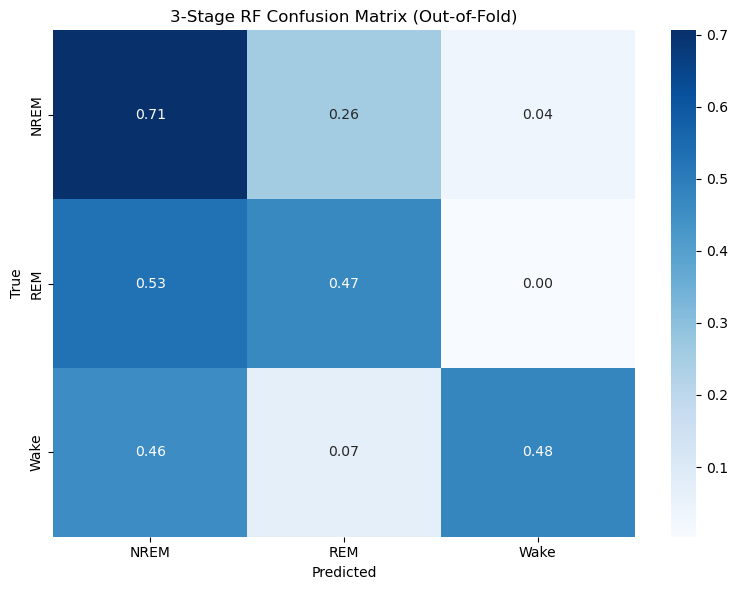

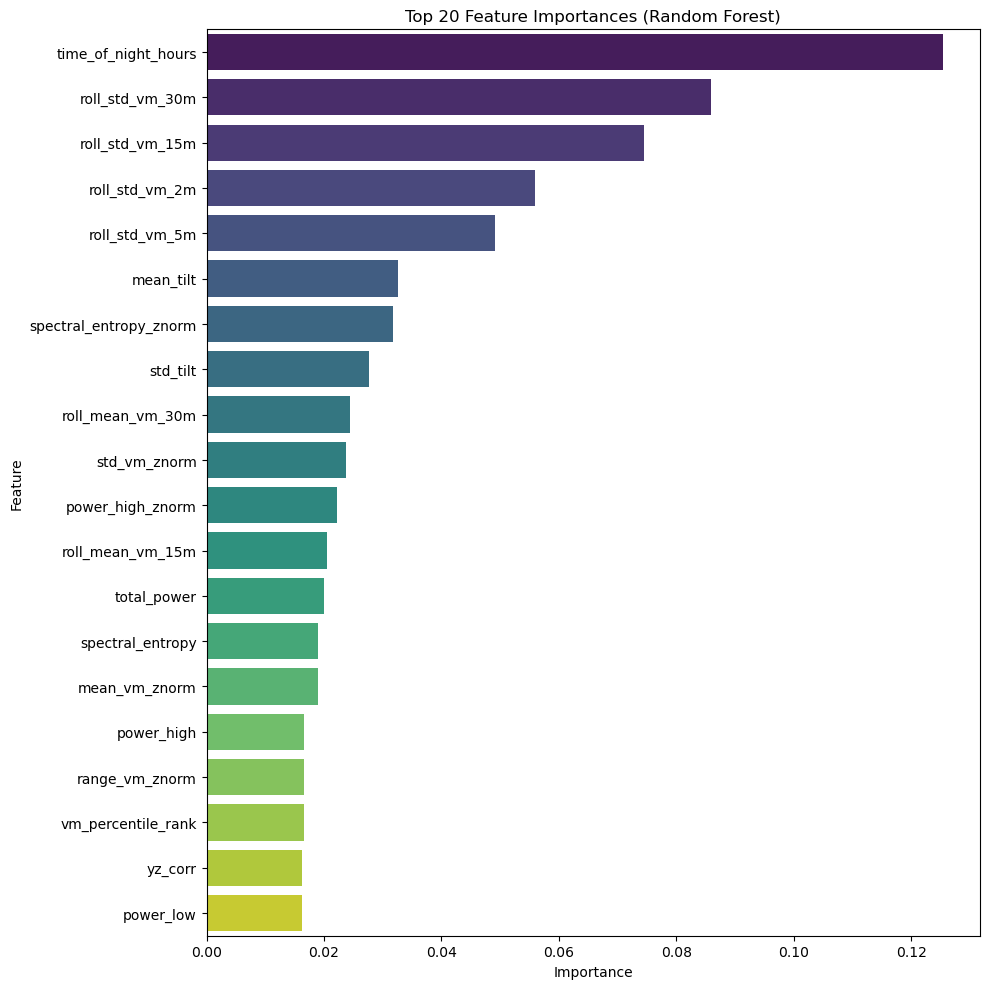


Top 10 features by importance:
               Feature  Importance
   time_of_night_hours    0.125456
       roll_std_vm_30m    0.085941
       roll_std_vm_15m    0.074549
        roll_std_vm_2m    0.055973
        roll_std_vm_5m    0.049150
             mean_tilt    0.032585
spectral_entropy_znorm    0.031692
              std_tilt    0.027579
      roll_mean_vm_30m    0.024401
          std_vm_znorm    0.023701


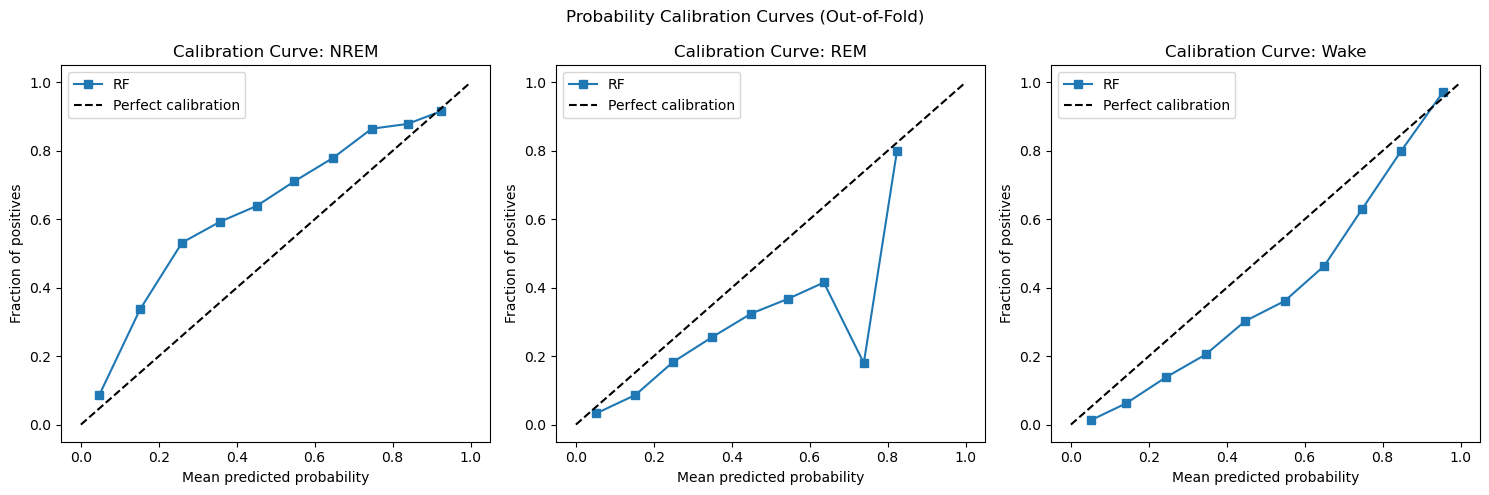

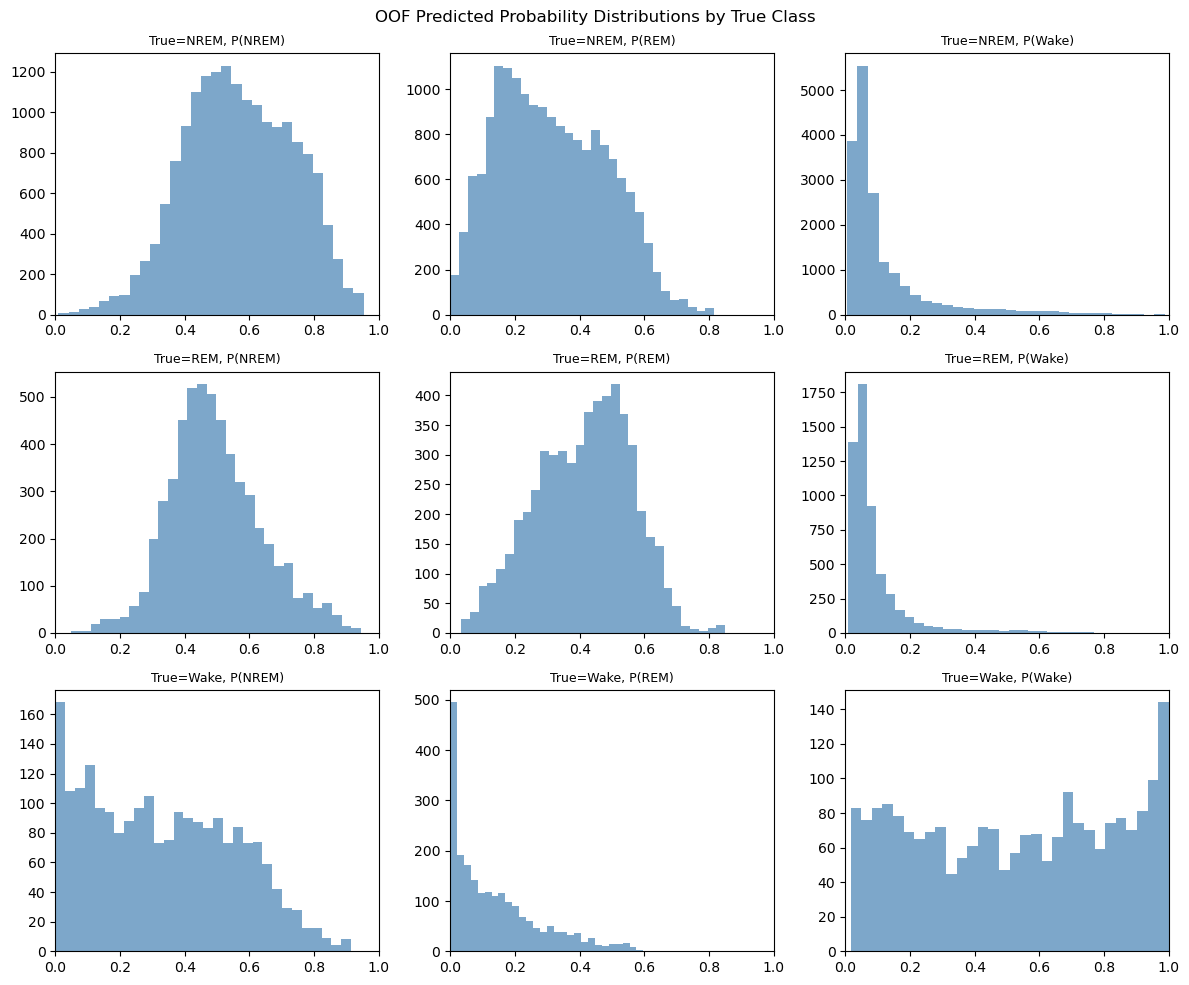


Out-of-Fold Summary:
  Accuracy : 63.37%
  Macro F1 : 0.5574
  Kappa    : 0.2426
All metrics reflect generalization performance via GroupKFold cross-validation.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              cohen_kappa_score, roc_auc_score)
from sklearn.calibration import calibration_curve

# --- 6.A Statistical Performance Report ---
print(f"3-Stage RF Report (REM Thresh: {best_thresh_rem:.2f}, Wake Thresh: {best_thresh_wake:.2f})")
print("[All metrics from out-of-fold predictions + bout enforcement]\n")
print(classification_report(y, y_pred_final))

# --- 6.B Cohen's Kappa ---
kappa = cohen_kappa_score(y, y_pred_final)
print(f"Cohen's Kappa: {kappa:.4f}")

# --- 6.C Per-Class AUC-ROC (One-vs-Rest) ---
print("\nPer-Class AUC-ROC (One-vs-Rest, from OOF probabilities):")
for i, cls in enumerate(classes):
    y_bin = (y == cls).astype(int)
    auc = roc_auc_score(y_bin, oof_probs[:, i])
    print(f"  AUC ({cls:>4}): {auc:.4f}")

# --- 6.D Confusion Matrix ---
cm = confusion_matrix(y, y_pred_final, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('3-Stage RF Confusion Matrix (Out-of-Fold)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# --- 6.E Feature Importance (from RF fit) ---
importances = rf_for_importance.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=fi_df.head(20),
            palette='viridis', legend=False)
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(fi_df.head(10).to_string(index=False))

# --- 6.F Calibration Curves (reliability diagrams) ---
# Perfect calibration = points on the diagonal. S-shaped = overconfidence.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, cls in enumerate(classes):
    y_bin = (y == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(y_bin, oof_probs[:, i], n_bins=10)
    axes[i].plot(mean_pred, frac_pos, 's-', label='RF')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[i].set_title(f'Calibration Curve: {cls}')
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend()
plt.suptitle('Probability Calibration Curves (Out-of-Fold)')
plt.tight_layout()
plt.show()

# --- 6.G OOF Probability Distributions ---
# Well-separated histograms = model distinguishes classes confidently.
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for row, true_cls in enumerate(classes):
    mask = (y == true_cls)
    for col, pred_cls in enumerate(classes):
        axes[row][col].hist(oof_probs[mask, col], bins=30, alpha=0.7, color='steelblue')
        axes[row][col].set_title(f'True={true_cls}, P({pred_cls})', fontsize=9)
        axes[row][col].set_xlim(0, 1)
plt.suptitle('OOF Predicted Probability Distributions by True Class')
plt.tight_layout()
plt.show()

# --- 6.H Summary ---
report_dict = classification_report(y, y_pred_final, output_dict=True)
macro_f1    = report_dict['macro avg']['f1-score']
accuracy    = report_dict['accuracy']

print(f"\nOut-of-Fold Summary:")
print(f"  Accuracy : {accuracy:.2%}")
print(f"  Macro F1 : {macro_f1:.4f}")
print(f"  Kappa    : {kappa:.4f}")
print("All metrics reflect generalization performance via GroupKFold cross-validation.")

## 7. Per-Subject Performance Breakdown

To assess variability across individuals, we compute F1 Macro for each subject and report mean and standard deviation. This validates whether "patient calibration" helps uniformly or benefits some subjects more than others.

Per-Subject F1 Macro: 0.5340 +/- 0.0997
  Min: 0.3553  Max: 0.8347

subject_id  f1_macro  rem_frac  wake_frac  nrem_frac
   1066528  0.355266  0.326087   0.177536   0.496377
   1360686  0.548187  0.224865   0.101622   0.673514
   1449548  0.435946  0.223476   0.115124   0.661400
   1455390  0.410458  0.188482   0.087958   0.723560
   1818471  0.471630  0.229645   0.010438   0.759916
   2598705  0.382723  0.260523   0.019340   0.720137
   2638030  0.697415  0.175105   0.129747   0.695148
   3509524  0.542029  0.115108   0.127098   0.757794
   3997827  0.586259  0.305846   0.026096   0.668058
   4018081  0.542502  0.070281   0.158635   0.771084
   4314139  0.497733  0.169615   0.108221   0.722164
   4426783  0.661040  0.309184   0.071429   0.619388
     46343  0.490254  0.205776   0.153430   0.640794
   5132496  0.429098  0.000000   0.070968   0.929032
   5383425  0.633540  0.342239   0.050891   0.606870
   5498603  0.584597  0.131898   0.142665   0.725437
   5797046  0.476075  0.157614 

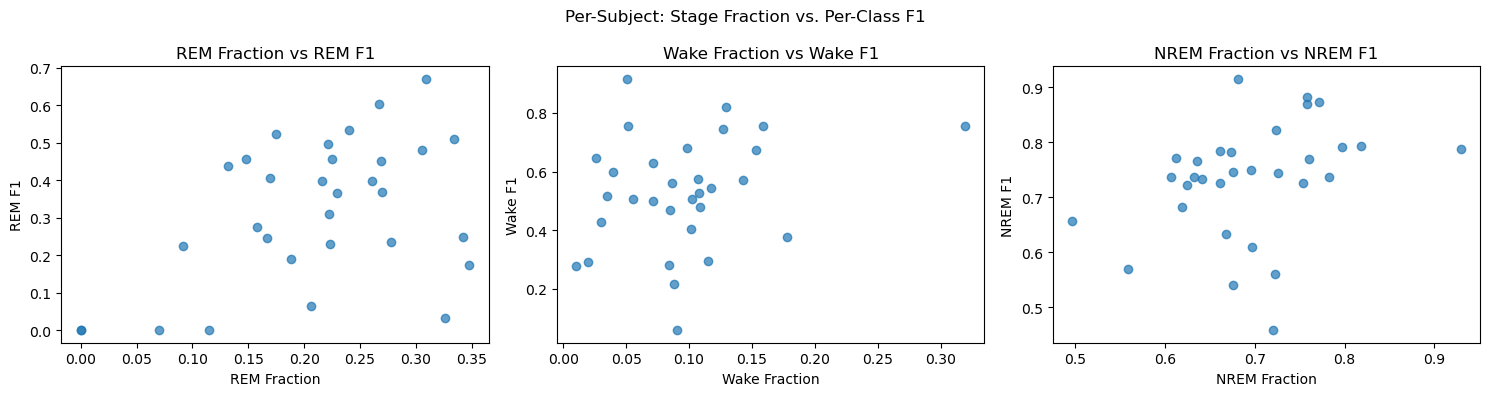

In [8]:
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

subject_stats = []
for sid in sorted(epoch_df['subject_id'].unique()):
    mask = (epoch_df['subject_id'] == sid).values
    if mask.sum() == 0:
        continue
    y_true_s = y.values[mask] if hasattr(y, 'values') else y[mask]
    y_pred_s = y_pred_final[mask]
    n_epochs = mask.sum()
    rem_frac  = (y_true_s == 'REM').mean()
    wake_frac = (y_true_s == 'Wake').mean()
    nrem_frac = (y_true_s == 'NREM').mean()
    f1_per_class = f1_score(y_true_s, y_pred_s, average=None,
                             labels=classes, zero_division=0)
    f1_macro = f1_score(y_true_s, y_pred_s, average='macro', zero_division=0)
    subject_stats.append({
        'subject_id': sid, 'n_epochs': n_epochs,
        'rem_frac': rem_frac, 'wake_frac': wake_frac, 'nrem_frac': nrem_frac,
        'f1_macro': f1_macro,
        **{f'f1_{cls}': f1_per_class[i] for i, cls in enumerate(classes)}
    })

subject_df = pd.DataFrame(subject_stats)
print(f"Per-Subject F1 Macro: {subject_df['f1_macro'].mean():.4f} +/- {subject_df['f1_macro'].std():.4f}")
print(f"  Min: {subject_df['f1_macro'].min():.4f}  Max: {subject_df['f1_macro'].max():.4f}")
print()
print(subject_df[['subject_id', 'f1_macro', 'rem_frac', 'wake_frac', 'nrem_frac']].to_string(index=False))

# --- 7.A Per-Subject Diagnostic: Stage Fraction vs. Per-Class F1 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x_col, x_label, y_col, y_label) in zip(axes, [
    ('rem_frac',  'REM Fraction',  'f1_REM',   'REM F1'),
    ('wake_frac', 'Wake Fraction', 'f1_Wake',  'Wake F1'),
    ('nrem_frac', 'NREM Fraction', 'f1_NREM',  'NREM F1'),
]):
    ax.scatter(subject_df[x_col], subject_df[y_col], alpha=0.7)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f'{x_label} vs {y_label}')
plt.suptitle('Per-Subject: Stage Fraction vs. Per-Class F1')
plt.tight_layout()
plt.show()

## 8. Hypnogram Visualization

Compare predicted vs. true sleep staging for one example subject. Hypnograms are the standard visualization in sleep medicine and provide intuitive assessment of temporal prediction accuracy.

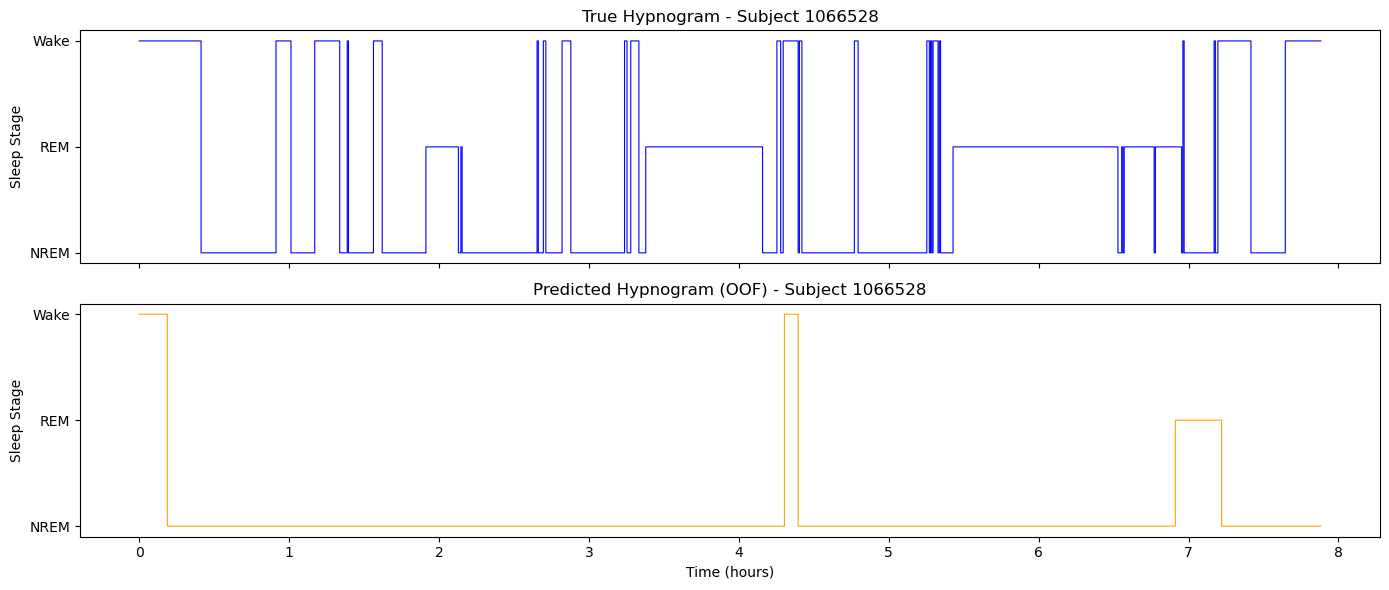

In [9]:
import matplotlib.pyplot as plt

# Pick the first subject deterministically
example_subject = sorted(epoch_df['subject_id'].unique())[0]
mask = (epoch_df['subject_id'] == example_subject).values

epochs = epoch_df.loc[mask, 'epoch_start'].values
y_true_subj = y.values[mask] if hasattr(y, 'values') else y[mask]
y_pred_subj = y_pred_final[mask]

stage_order = {'Wake': 2, 'REM': 1, 'NREM': 0}
ytick_labels = ['NREM', 'REM', 'Wake']

true_numeric = [stage_order[s] for s in y_true_subj]
pred_numeric = [stage_order[s] for s in y_pred_subj]

hours = (epochs - epochs[0]) / 3600.0

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].step(hours, true_numeric, where='mid', color='blue', linewidth=0.8)
axes[0].set_yticks(range(len(ytick_labels)))
axes[0].set_yticklabels(ytick_labels)
axes[0].set_title(f'True Hypnogram - Subject {example_subject}')
axes[0].set_ylabel('Sleep Stage')

axes[1].step(hours, pred_numeric, where='mid', color='orange', linewidth=0.8)
axes[1].set_yticks(range(len(ytick_labels)))
axes[1].set_yticklabels(ytick_labels)
axes[1].set_title(f'Predicted Hypnogram (OOF) - Subject {example_subject}')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Sleep Stage')

plt.tight_layout()
plt.show()